In [1]:
import pandas as pd
path = 'TS (1).csv'
df = pd.read_csv(path)
df


,Time,Users
0,1/1/17 0:00,34002
1,1/1/17 1:00,37947
2,1/1/17 2:00,41517
3,1/1/17 3:00,44476
4,1/1/17 4:00,46234
...,...,...
2620,4/20/17 5:00,34833
2621,4/20/17 6:00,35932
2622,4/20/17 7:00,38418
2623,4/20/17 8:00,40238


In [4]:
df1 = pd.date_range('1/1/17', periods=744, freq='h')
ts1 = pd.Series(range(744), index=df1)

In [6]:
df2 = pd.date_range('1/1/17', periods=28, freq='D')
ts2 = pd.Series(range(28), index=df2)


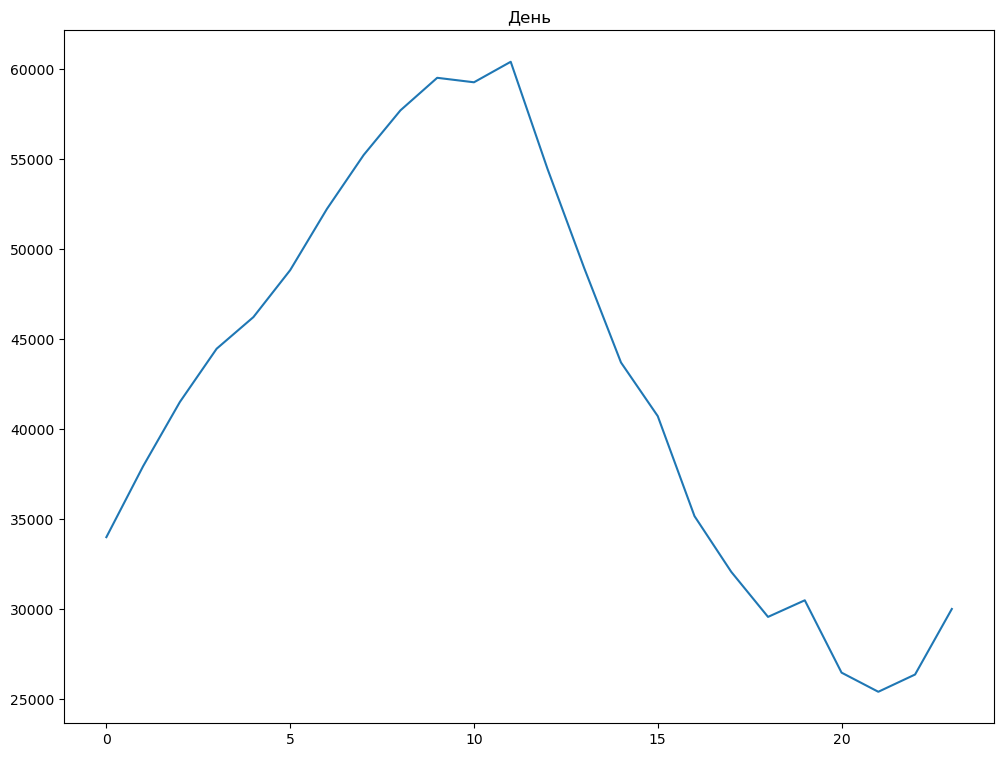

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (12, 9))
df[:24]['Users'].plot()
plt.title('День')
plt.show()


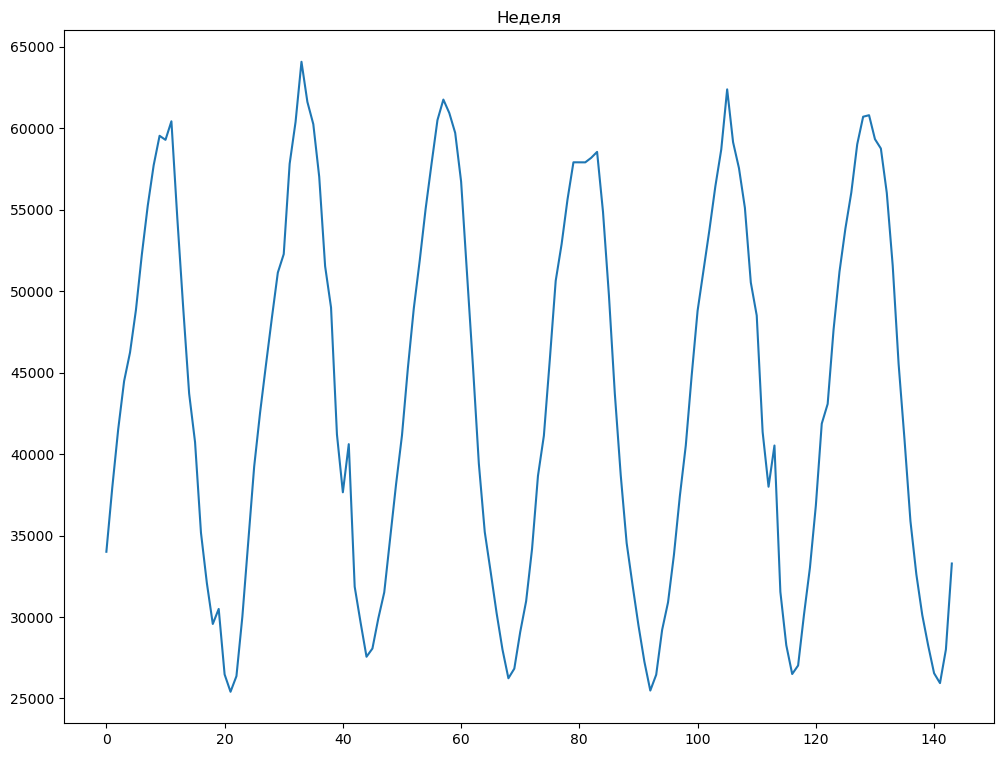

In [10]:
plt.figure(figsize = (12, 9))
df[:144]['Users'].plot()
plt.title('Неделя')
plt.show()


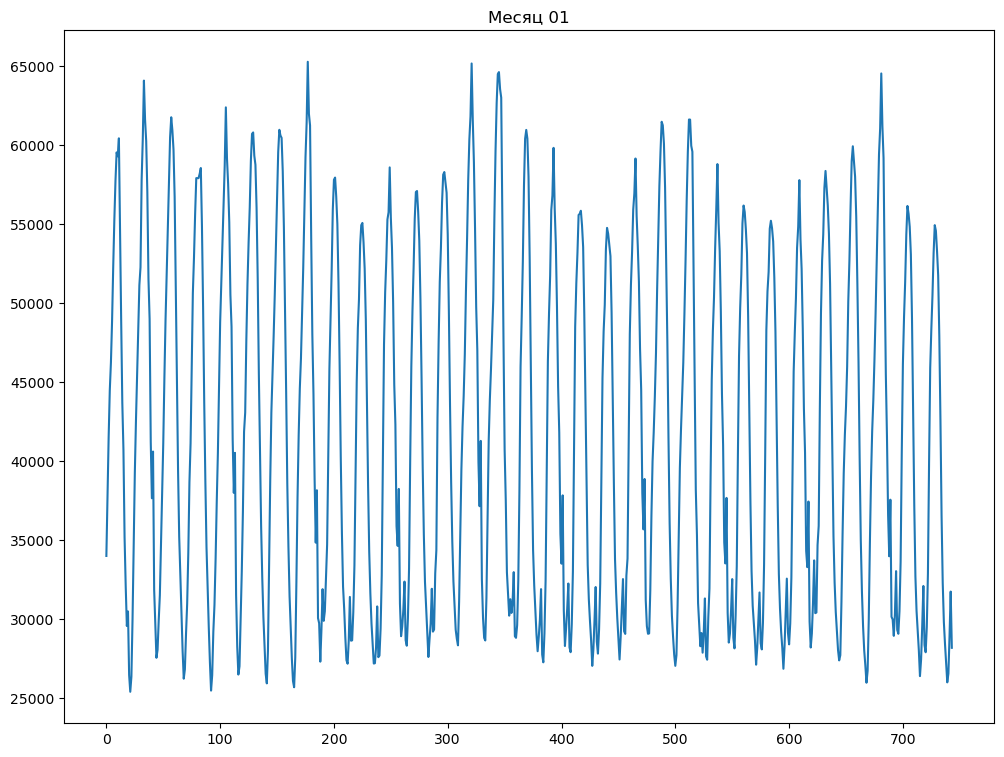

In [11]:
plt.figure(figsize = (12, 9))
df[:744]['Users'].plot()
plt.title('Месяц 01')
plt.show()


In [12]:
yanuar = df[:744]


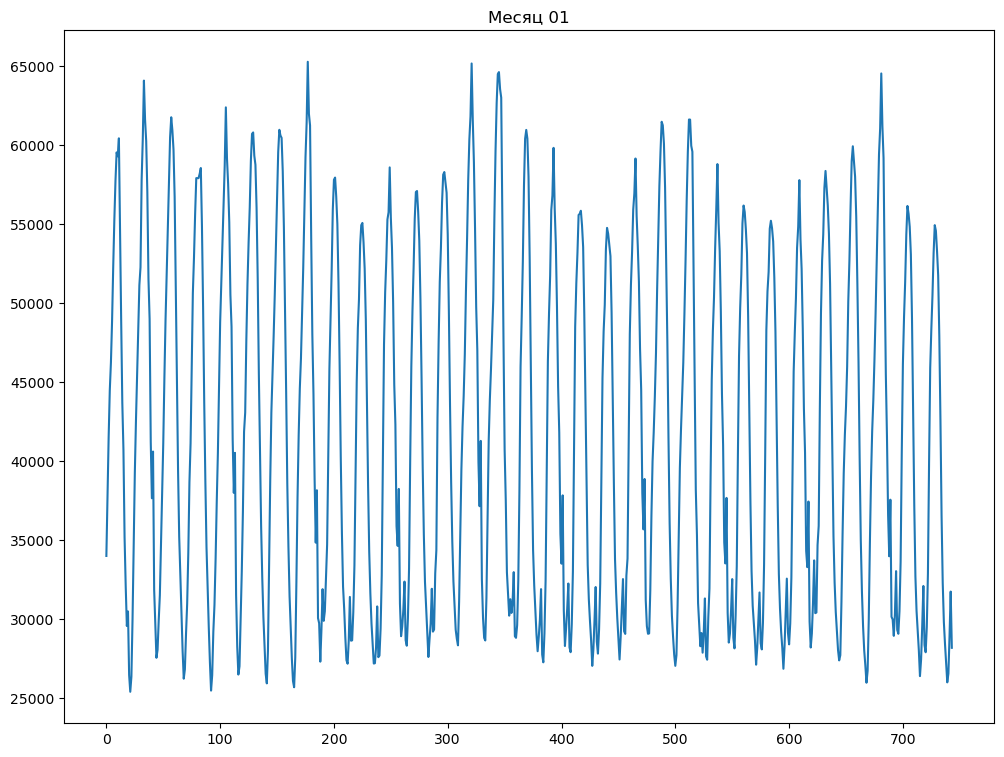

In [13]:
plt.figure(figsize = (12, 9))
yanuar['Users'].plot()
plt.title('Месяц 01')
plt.show()


In [16]:
start_data = '2/1/17 0:00'
end_data = '2/28/17 23:00'
data = df['Users'].values[:744]  
print(f"Январь: {len(data)} часов")

Январь: 744 часов


In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1, 1)).flatten()

In [25]:
import numpy as np
def create_dataset(data, lookback=168):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lookback = 24
X, y = create_dataset(data_scaled, lookback)
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (720, 24), y shape: (720,)


In [26]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 576, Test: 144


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 32
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 18, Test batches: 5


In [28]:
class MLP(nn.Module):
    def __init__(self, input_size=24, hidden_size=64):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

model = MLP()
print(model)
print(f"Параметры модели: {sum(p.numel() for p in model.parameters())}")

MLP(
  (fc1): Linear(in_features=24, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)
Параметры модели: 3713


In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch).squeeze()
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        avg_loss = train_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')

Используется устройство: cpu
Epoch [10/50], Loss: 0.0103
Epoch [20/50], Loss: 0.0094
Epoch [30/50], Loss: 0.0078
Epoch [40/50], Loss: 0.0069
Epoch [50/50], Loss: 0.0073


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

model.eval()
preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch).squeeze().cpu().numpy()
        preds.extend(output)

preds = np.array(preds)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
preds_inv = scaler.inverse_transform(preds.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_test_inv, preds_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, preds_inv))
print(f'Test MAE: {mae:.2f}, RMSE: {rmse:.2f}')

Test MAE: 1682.57, RMSE: 2137.67


In [31]:
print(df['Users'].describe())
print(f"Min: {df['Users'].min()}, Max: {df['Users'].max()}, Mean: {df['Users'].mean():.1f}")

count      2625.000000
mean      40483.884190
std       14304.659157
min           0.000000
25%       29346.000000
50%       38314.000000
75%       48996.000000
max      110716.000000
Name: Users, dtype: float64
Min: 0, Max: 110716, Mean: 40483.9


In [38]:
def forecast(model, last_sequence, steps, scaler, device, lookback=24):
    model.eval()
    predictions = []
    current_seq = last_sequence.copy()
    
    with torch.no_grad():
        for _ in range(steps):
            input_seq = torch.tensor(current_seq[-lookback:], 
                                   dtype=torch.float32).unsqueeze(0).to(device)
            pred = model(input_seq).item()
            predictions.append(pred)
            current_seq = np.append(current_seq, pred)
    
    predictions = np.array(predictions).reshape(-1, 1)
    return scaler.inverse_transform(predictions).flatten()


last_seq = data_scaled[-lookback:]
february_pred = forecast(model, last_seq, 672, scaler, device)  
print(f"Прогноз февраля: {len(february_pred)} часов")

Прогноз февраля: 672 часов


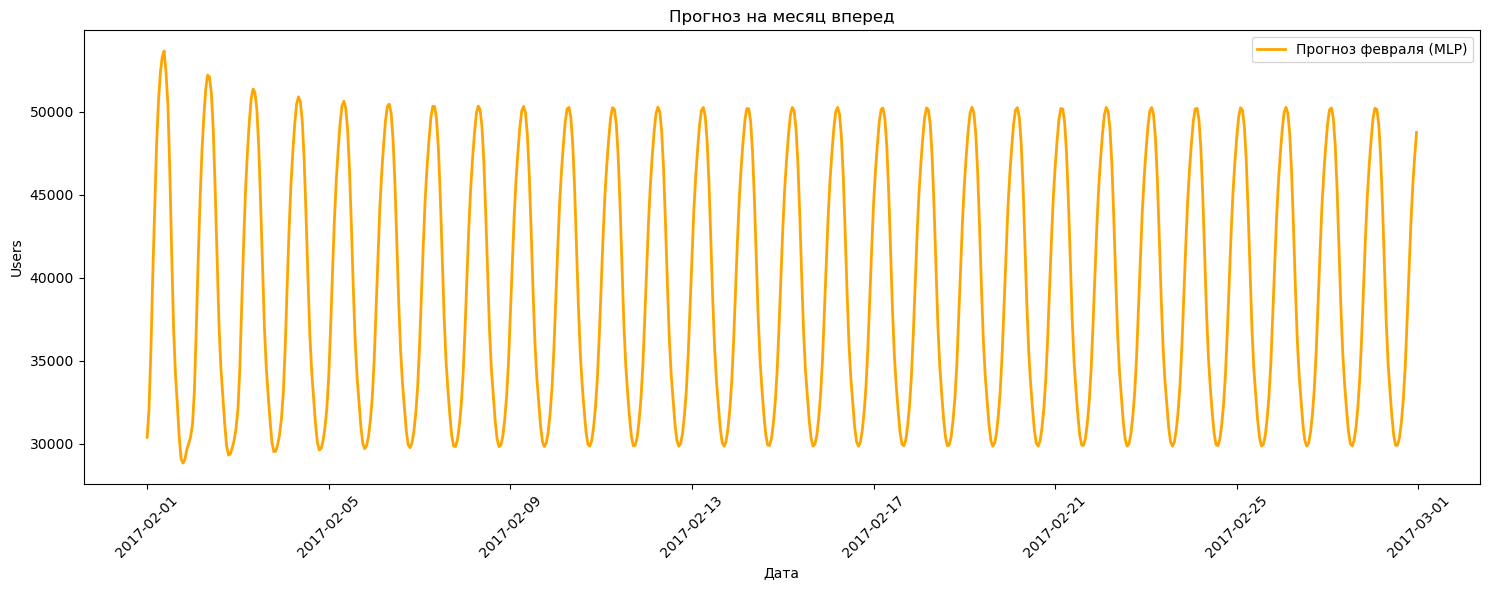

In [39]:
february_dates = pd.date_range('2/1/17', periods=672, freq='h')

plt.figure(figsize=(15, 6))
plt.plot(february_dates, february_pred, label='Прогноз февраля (MLP)', 
         color='orange', linewidth=2)

if len(test_df) > 0 and 'Date' in test_df.columns:
    test_df['Date'] = pd.to_datetime(test_df['Date'])
    plt.plot(test_df['Date'], test_df['Users'], label='Факт февраля', 
             color='red', alpha=0.7)

plt.title('Прогноз на месяц вперед')
plt.xlabel('Дата')
plt.ylabel('Users')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
